In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

--> DATA PREPROCESSING

1.Check basic statistics of dataset

2.Check for missing values in the data

3.check for unique values in data

-->Perform EDA

1.Purchase Distribution

2.check for outliers

3.Analysis by Gender, Marital Status, occupation, occupation vs purchase , purchase by city, purchase by age group, etc

4.Drop unnecessary fields

5.Convert categorical data into integer using map function (e.g 'Gender' column)

6.missing value treatment

7.Rename columns

8.fill nan values

9.map range variables into integers (e.g 'Age' column)

-->Data Visualisation

-->visualize individul column
1.Age vs Purchased

2.Occupation vs Purchased

3.Product_category_1 vs Purchased

4.Product_category_2 vs Purchased

5.Product_category_3 vs Purchased

6.City category pie chart

7.check for more possible plots

## Data Processing

In [3]:
df=pd.read_csv('train.csv')

In [4]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


In [6]:
df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

## eda 

In [7]:
## replacing the str F and M value 
df['Gender']=df['Gender'].replace({'F':0})
df['Gender']=df['Gender'].replace({'M':1})


C:\Users\Admin\AppData\Local\Temp\ipykernel_11412\943385615.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender']=df['Gender'].replace({'M':1})


In [8]:
df['Gender'].astype(int)

0         0
1         0
2         0
3         0
4         1
         ..
550063    1
550064    0
550065    0
550066    0
550067    0
Name: Gender, Length: 550068, dtype: int64

In [9]:
## replacing value of age to normalized
df['Age'].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [10]:
df['Age'] = df['Age'].str.replace(r'55\+', '55', regex=True)


In [11]:
df['Age']=df['Age'].str.replace(r'0-17','child',regex=True)
df['Age']=df['Age'].str.replace(r'18-25','Tenagger',regex=True)
df['Age']=df['Age'].str.replace(r'26-35','Adult',regex=True)
df['Age']=df['Age'].str.replace(r'36-45','Adult',regex=True)
df['Age']=df['Age'].str.replace(r'46-50','Adult',regex=True)
df['Age']=df['Age'].str.replace(r'51-55','old',regex=True)
df['Age']=df['Age'].str.replace(r'55','old+',regex=True)

In [12]:
df['Age'].unique()

array(['child', 'old+', 'Adult', 'old', 'Tenagger'], dtype=object)

In [13]:
## occupation 
df['Occupation']=df['Occupation'].astype(int)

In [14]:
df['Occupation']

0         10
1         10
2         10
3         10
4         16
          ..
550063    13
550064     1
550065    15
550066     1
550067     0
Name: Occupation, Length: 550068, dtype: int64

In [15]:
##replacing value of  Stay_In_Current_City_Years to normalized
df['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

In [16]:
df['Stay_In_Current_City_Years']=df['Stay_In_Current_City_Years'].replace(r'4\+','4',regex=True).astype(int)

In [17]:
df['Stay_In_Current_City_Years']

0         2
1         2
2         2
3         2
4         4
         ..
550063    1
550064    3
550065    4
550066    2
550067    4
Name: Stay_In_Current_City_Years, Length: 550068, dtype: int64

In [18]:
## observaing martial status
df['Marital_Status'].unique()

array([0, 1])

In [19]:
df['Marital_Status']=df['Marital_Status'].replace(0,'Single',regex=True)
df['Marital_Status']=df['Marital_Status'].replace(1,'Married',regex=True)

In [20]:
df['Marital_Status'].astype(str)

0          Single
1          Single
2          Single
3          Single
4          Single
           ...   
550063    Married
550064     Single
550065    Married
550066     Single
550067    Married
Name: Marital_Status, Length: 550068, dtype: object

In [21]:
## handling missing values of product category 2
df['Product_Category_2'].isnull().sum()

np.int64(173638)

In [22]:
df['Product_Category_2'].unique()

array([nan,  6., 14.,  2.,  8., 15., 16., 11.,  5.,  3.,  4., 12.,  9.,
       10., 17., 13.,  7., 18.])

In [23]:
df['Product_Category_2']=df['Product_Category_2'].fillna(df['Product_Category_2'].mean())

In [24]:
## ## handling missing values of product category 3
df['Product_Category_3']=df['Product_Category_3'].fillna(df['Product_Category_3'].mean())

In [25]:
df['Product_Category_3'].isnull().sum()

np.int64(0)

In [26]:
df['Product_Category_3']

0         12.668243
1         14.000000
2         12.668243
3         12.668243
4         12.668243
            ...    
550063    12.668243
550064    12.668243
550065    12.668243
550066    12.668243
550067    12.668243
Name: Product_Category_3, Length: 550068, dtype: float64

In [27]:
df.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64

In [28]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,0,child,10,A,2,Single,3,9.842329,12.668243,8370
1,1000001,P00248942,0,child,10,A,2,Single,1,6.000000,14.000000,15200
2,1000001,P00087842,0,child,10,A,2,Single,12,9.842329,12.668243,1422
3,1000001,P00085442,0,child,10,A,2,Single,12,14.000000,12.668243,1057
4,1000002,P00285442,1,old+,16,C,4,Single,8,9.842329,12.668243,7969


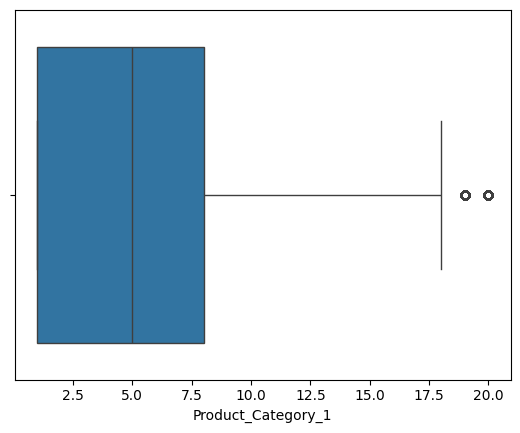

In [29]:
## Handling outliers from sklearn.ensemble import IsolationForest

sns.boxplot(x=df['Product_Category_1'])
plt.show()


In [30]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,0,child,10,A,2,Single,3,9.842329,12.668243,8370
1,1000001,P00248942,0,child,10,A,2,Single,1,6.000000,14.000000,15200
2,1000001,P00087842,0,child,10,A,2,Single,12,9.842329,12.668243,1422
3,1000001,P00085442,0,child,10,A,2,Single,12,14.000000,12.668243,1057
4,1000002,P00285442,1,old+,16,C,4,Single,8,9.842329,12.668243,7969


## visualization process 

In [116]:

numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 7 numerical features : ['User_ID', 'Occupation', 'Stay_In_Current_City_Years', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'Purchase']

We have 5 categorical features : ['Product_ID', 'Gender', 'Age', 'City_Category', 'Marital_Status']


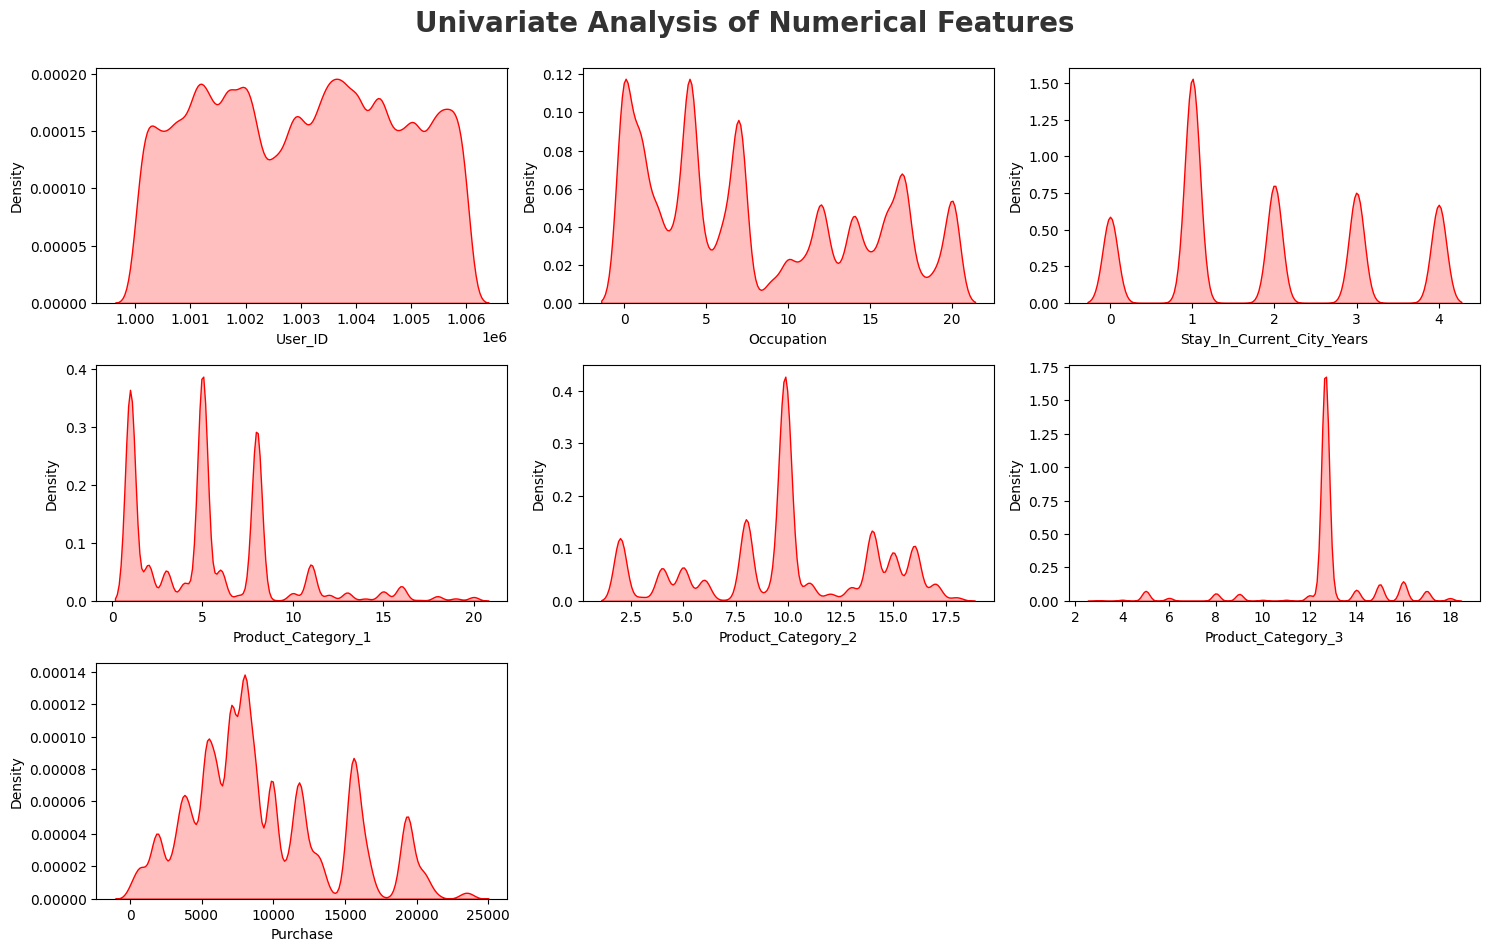

In [117]:
## Proportion of count data on numerical columns
plt.figure(figsize=(15, 15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df[numeric_features[i]],fill=True, color='r')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

 ### Now let's take broad overview of all columns indivually.

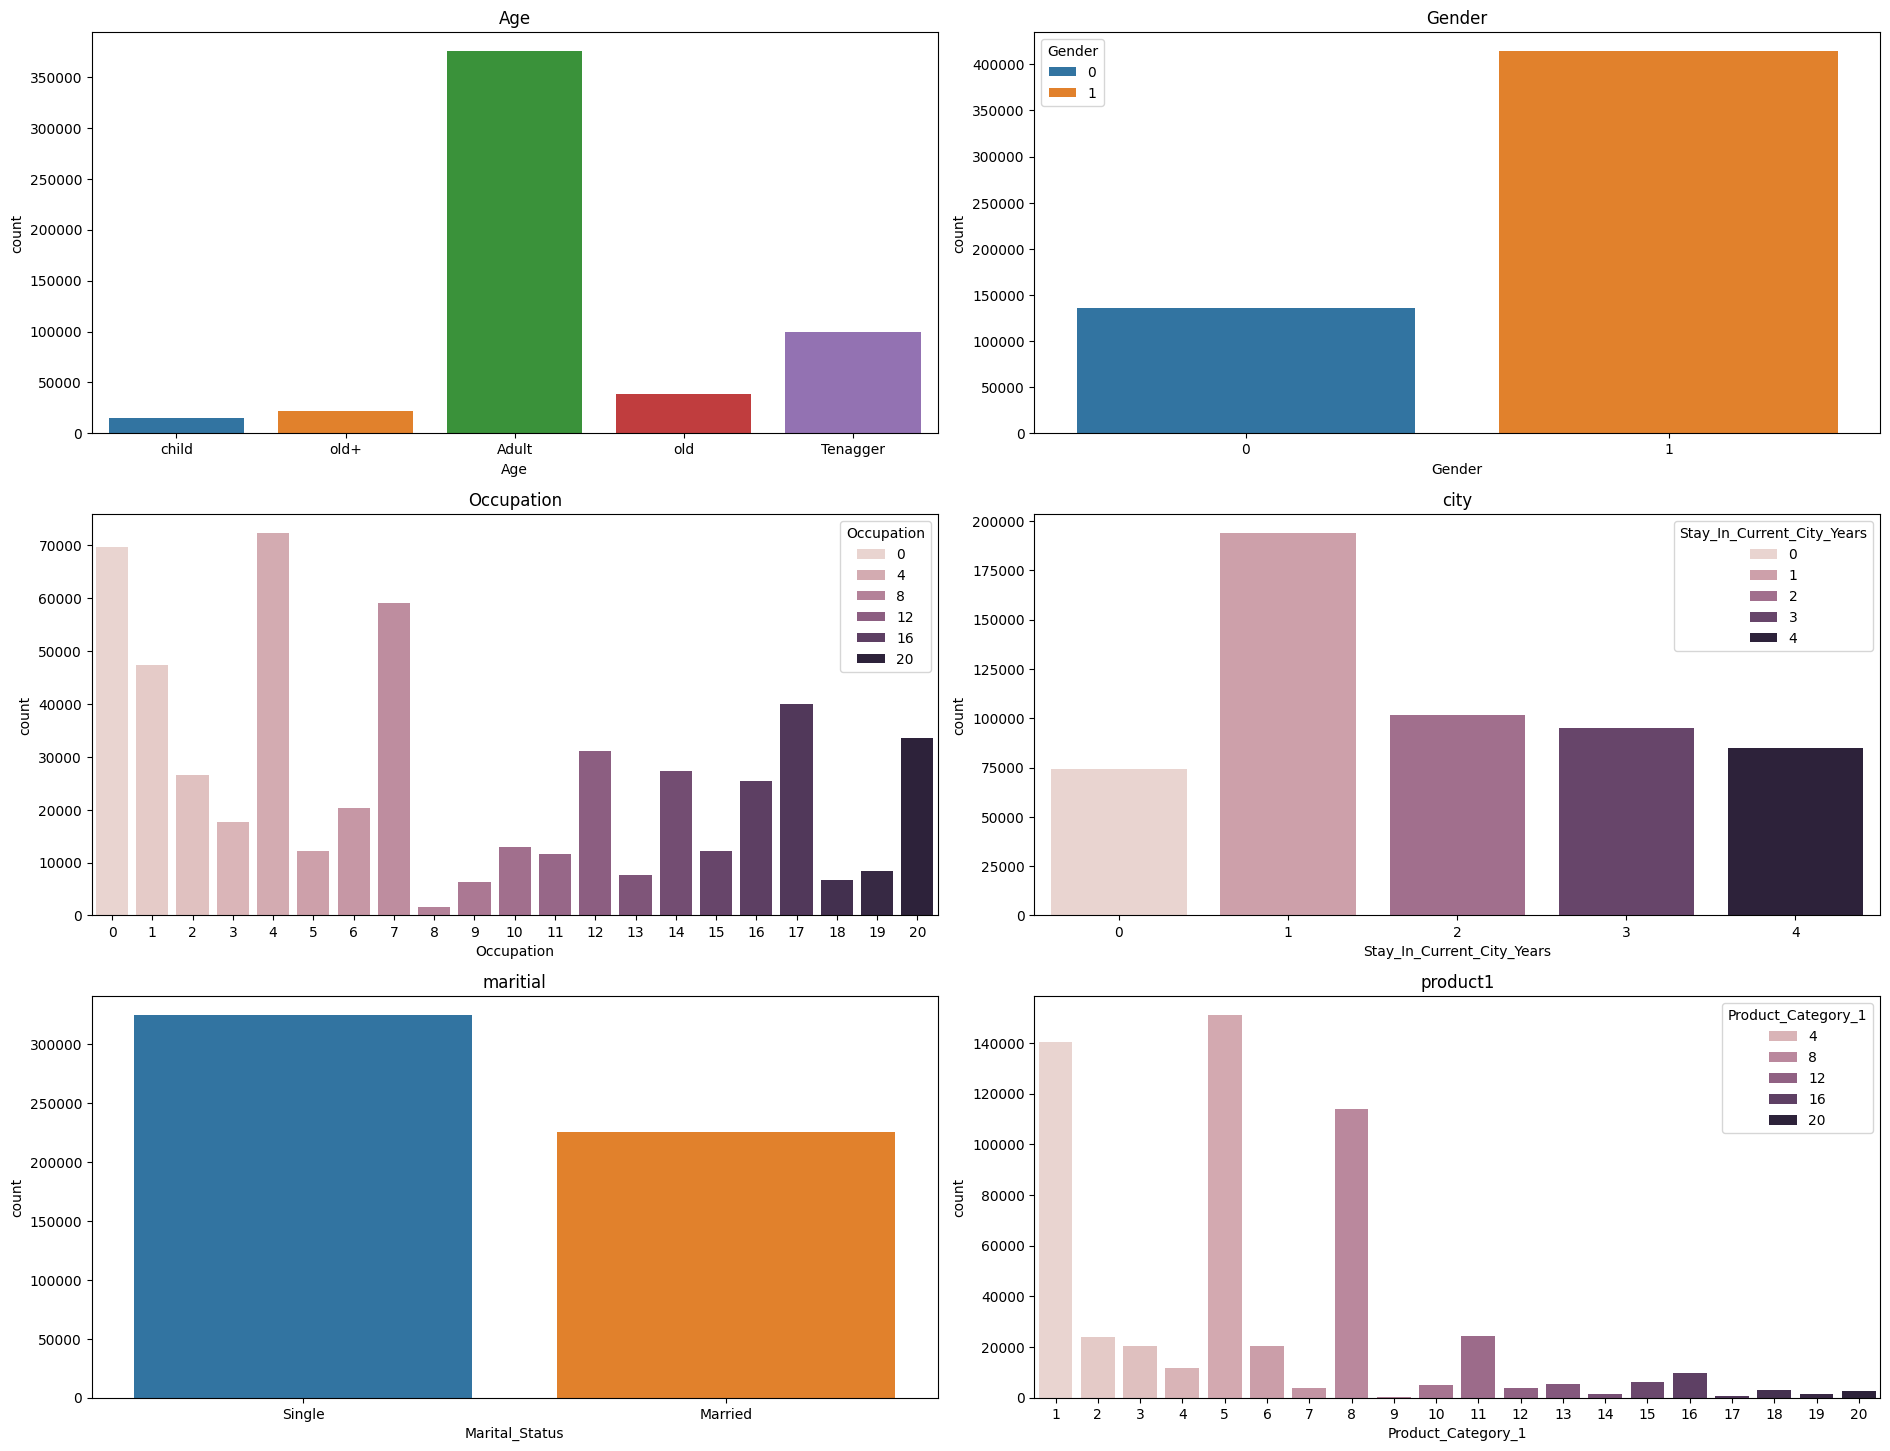

In [159]:
# now let take brod overview of all column indivually

plt.figure(figsize=(19,19))
plt.subplot(4,2,1)
plt.title('Age')
sns.countplot(x= 'Age', data = df , hue='Age')

plt.subplot(4,2,2)
plt.title('Gender')
sns.countplot(x= 'Gender', data = df , hue='Gender')

plt.subplot(4,2,3)
plt.title('Occupation')
sns.countplot(x= 'Occupation', data = df , hue='Occupation')

plt.subplot(4,2,4)
plt.title('city')
sns.countplot(x= 'Stay_In_Current_City_Years', data = df , hue='Stay_In_Current_City_Years')

plt.subplot(4,2,5)
plt.title('maritial')
sns.countplot(x= 'Marital_Status', data = df , hue='Marital_Status')

plt.subplot(4,2,6)
plt.title('product1')
sns.countplot(x= 'Product_Category_1', data = df , hue='Product_Category_1')

plt.tight_layout()
plt.show()

1.Age vs Purchased

2.Occupation vs Purchased

3.Product_category_1 vs Purchased

4.Product_category_2 vs Purchased

5.Product_category_3 vs Purchased

6.City category pie chart



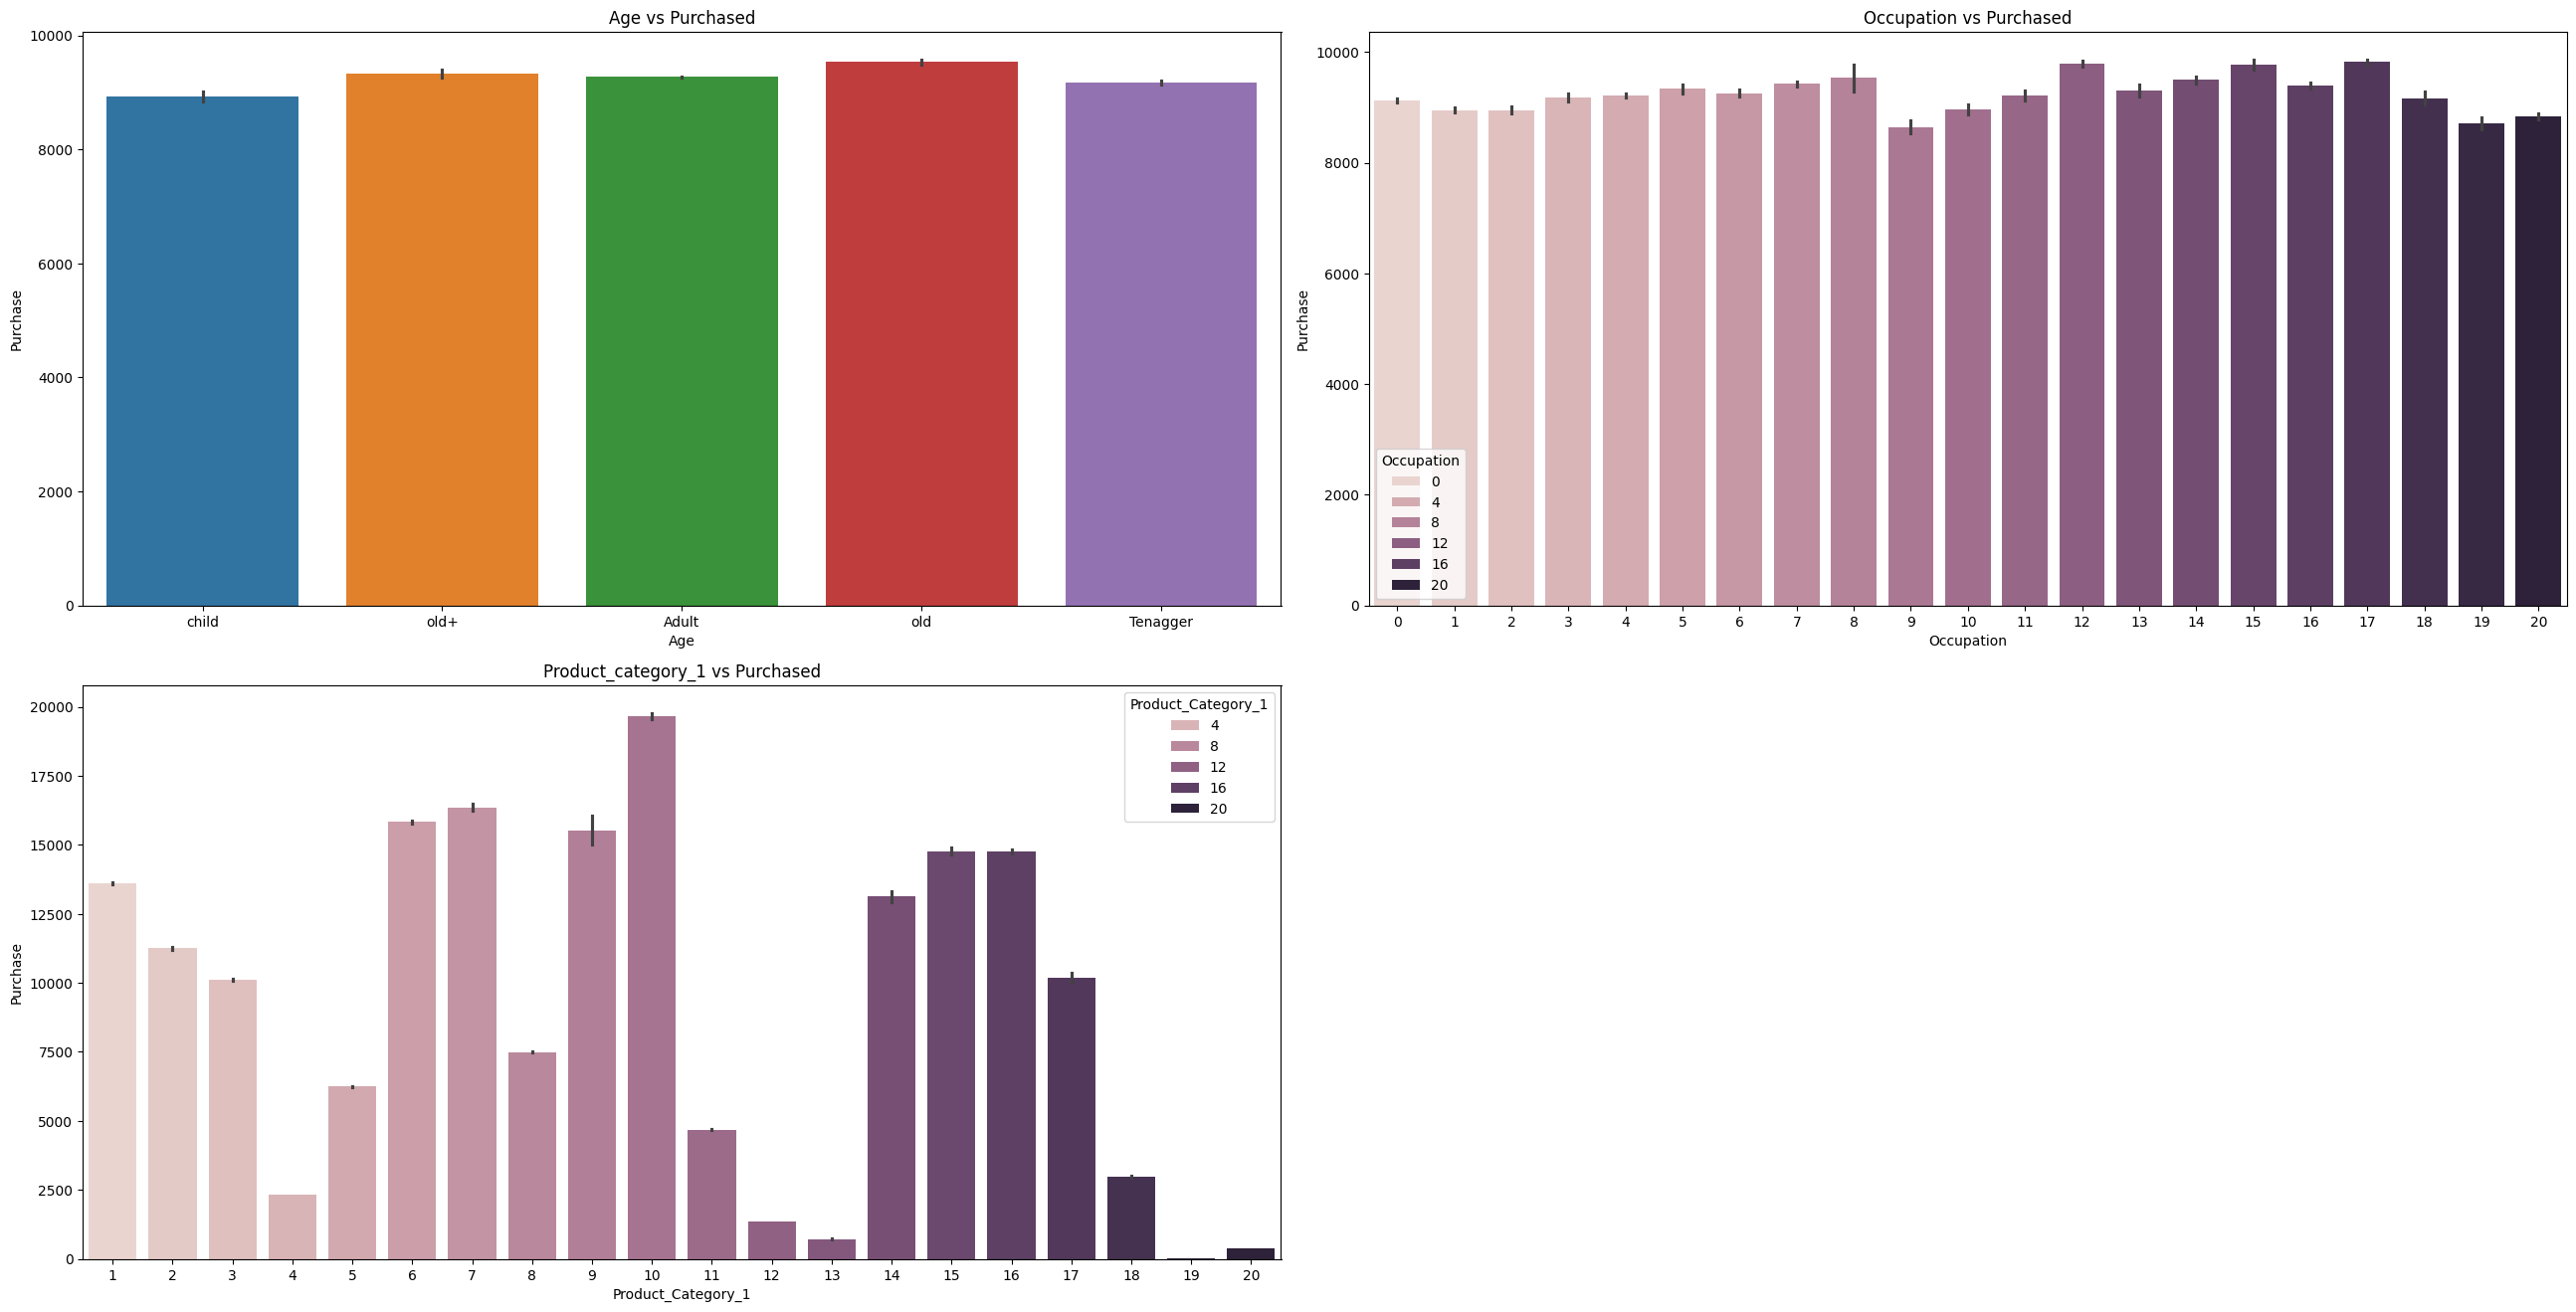

In [165]:
plt.figure(figsize=(26,26))
plt.subplot(4,2,1)
sns.barplot(data=df, x='Age', y='Purchase',  hue='Age')
plt.title("Age vs Purchased")


plt.subplot(4,2,2)
sns.barplot(data=df, x='Occupation', y='Purchase',  hue='Occupation')
plt.title("Occupation vs Purchased")

plt.subplot(4,2,3)
sns.barplot(data=df, x='Product_Category_1', y='Purchase',  hue='Product_Category_1')
plt.title("Product_category_1 vs Purchased")




plt.tight_layout()
plt.show()





Text(0.5, 1.0, 'Product_category_2 vs Purchased')

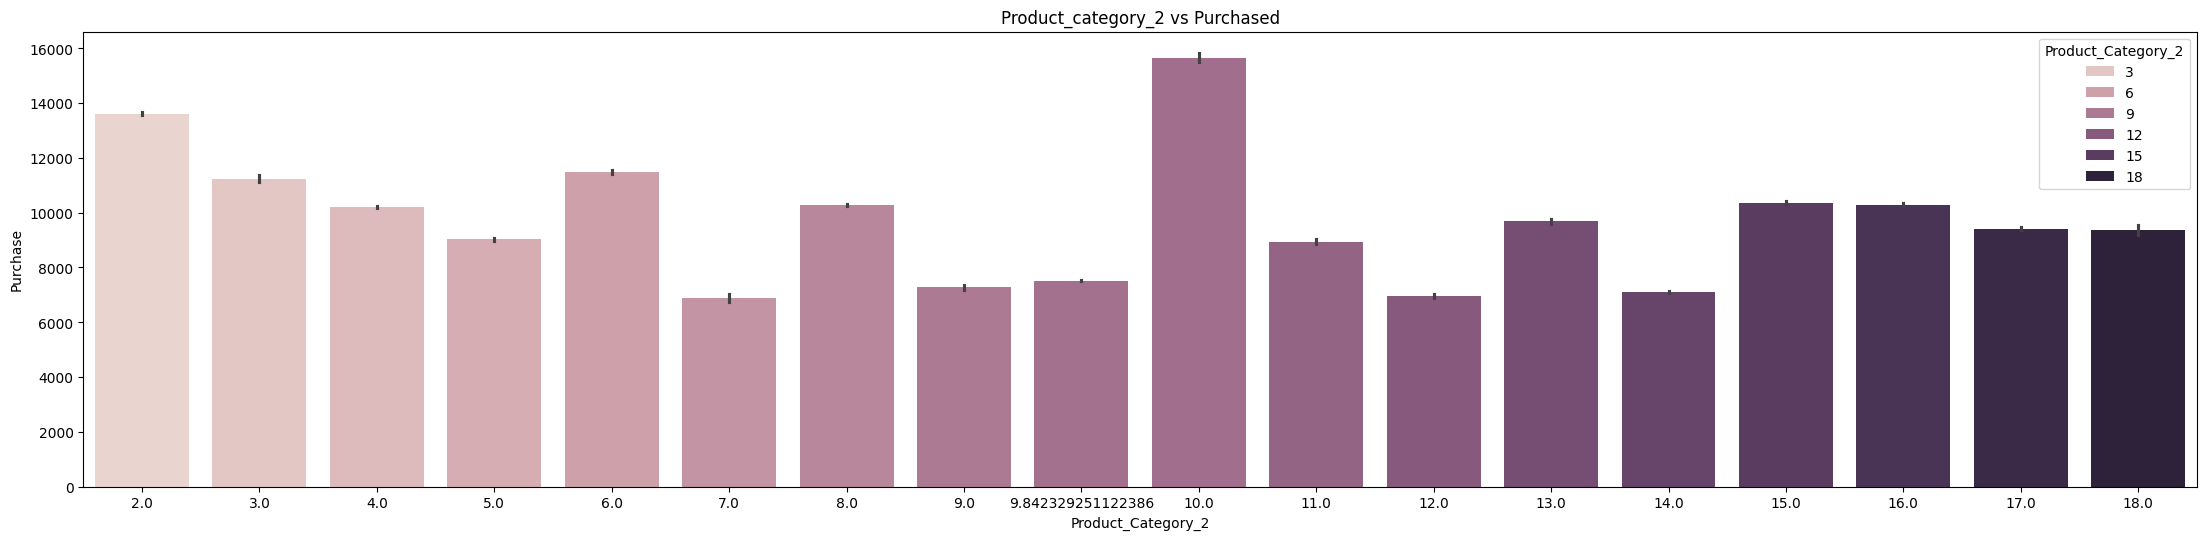

In [195]:
plt.figure(figsize=(60,13))
plt.subplot(2,2,1)
sns.barplot(data=df, x='Product_Category_2', y='Purchase',  hue='Product_Category_2')
plt.title("Product_category_2 vs Purchased")



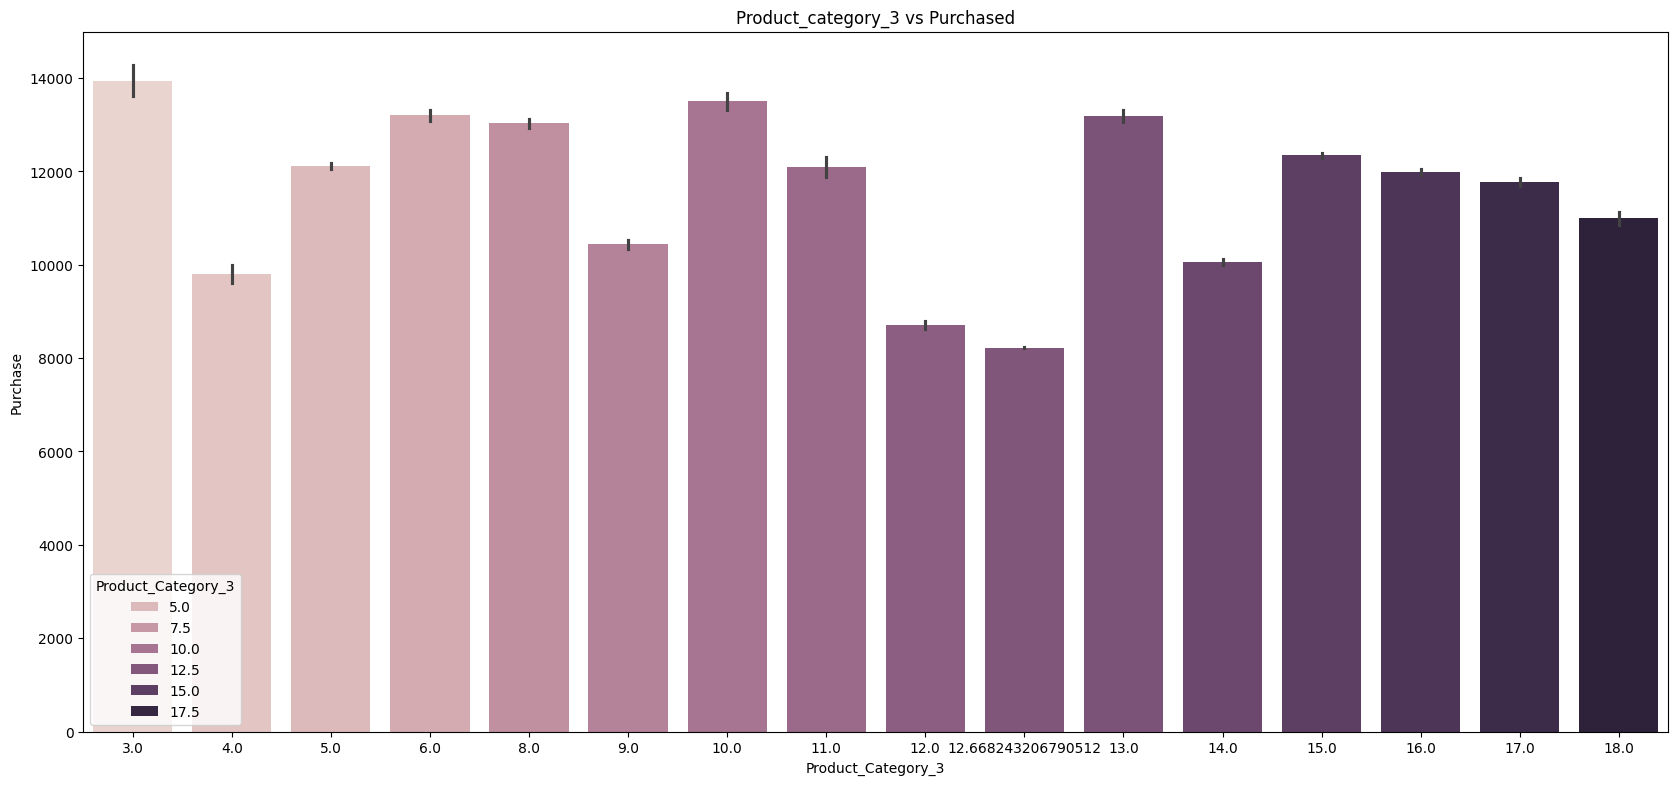

In [196]:
plt.figure(figsize=(45,20))
plt.subplot(2,2,1)
sns.barplot(data=df, x='Product_Category_3', y='Purchase',  hue='Product_Category_3')
plt.title("Product_category_3 vs Purchased")
plt.show()

<Axes: ylabel='count'>

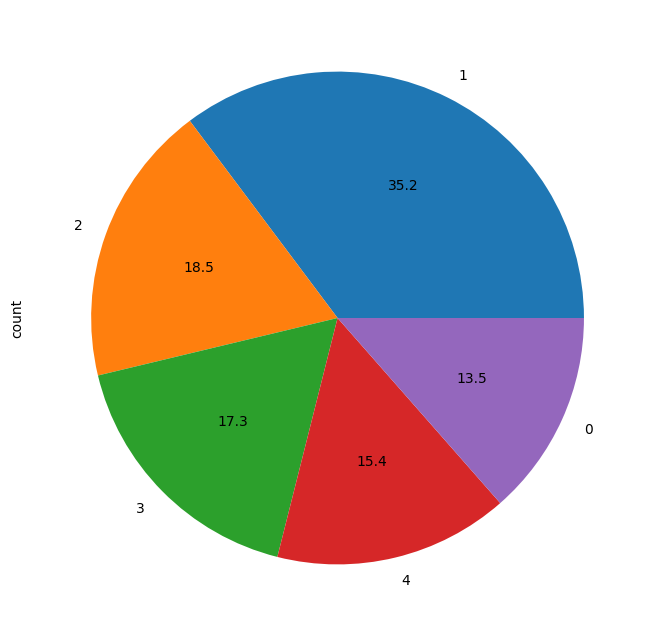

In [ ]:
## city pie charts
df['Stay_In_Current_City_Years'].value_counts().plot.pie(y=df['Stay_In_Current_City_Years'],figsize=(8,8),autopct='%1.1f')

In [31]:
df.to_csv('train1.csv')